# Homework 1: 3D Cube Projection & Wireframe Rendering - (Noah Crouch)

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

In [11]:
# Returns the vertices, edges, and point labels for a cube centered at the origin with side length 2.
def make_cube():
    V = np.array(
        [
            [-1, -1, -1],  # A
            [1, -1, -1],   # B
            [1, 1, -1],    # C
            [-1, 1, -1],   # D
            [-1, -1, 1],   # E
            [1, -1, 1],    # F
            [1, 1, 1],     # G
            [-1, 1, 1],    # H
        ],
        dtype=float,
    )
    E = np.array(
        [
            [0, 1], [1, 2], [2, 3], [3, 0],  # back face (z = -1)
            [4, 5], [5, 6], [6, 7], [7, 4],  # front face (z = +1)
            [0, 4], [1, 5], [2, 6], [3, 7],  # connectors
        ],
        dtype=int,
    )
    labels = list("ABCDEFGH")
    return V, E, labels

In [12]:
# Translates world cordinates to camera cordinates
def world_to_camera(V, camera_pos):
    return V - np.asarray(camera_pos, dtype=float)

In [13]:
# Projects camera coordinates to 2D image coordinates using a simple pinhole camera model.
def project_vertices(V, camera_pos, f=1.0, near=1e-3):
    p = world_to_camera(V, camera_pos)
    z = np.minimum(p[:, 2], -near)
    return -f * p[:, :2] / z[:, None]

In [14]:
# Plots the projected cube in 2D image coordinates.
def plot_projection(U, E, labels, camera_pos, out="projected_cube.png"):
    fig, ax = plt.subplots(figsize=(7, 7))

    ax.add_collection(LineCollection(U[E], colors="teal", linewidths=1.5))
    ax.scatter(U[:, 0], U[:, 1], c="crimson", zorder=3)
    for name, (u, v) in zip(labels, U):
        ax.annotate(
            f"{name} ({u:.2f}, {v:.2f})",
            (u, v),
            xytext=(4, 4),
            textcoords="offset points",
            fontweight="bold",
            fontsize=8,
        )

    ax.set_aspect("equal")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_xlabel("u (Image Plane X)")
    ax.set_ylabel("v (Image Plane Y)")
    ax.set_title(f"Pinhole Perspective Projection of 3D Cube\ncamera = {tuple(camera_pos)}")
    ax.autoscale()
    ax.margins(0.1)

    fig.savefig(out, dpi=150, bbox_inches="tight")
    return fig, ax

A: (-0.143, -0.286)
B: (+0.143, -0.286)
C: (+0.143, +0.000)
D: (-0.143, +0.000)
E: (-0.200, -0.400)
F: (+0.200, -0.400)
G: (+0.200, +0.000)
H: (-0.200, +0.000)


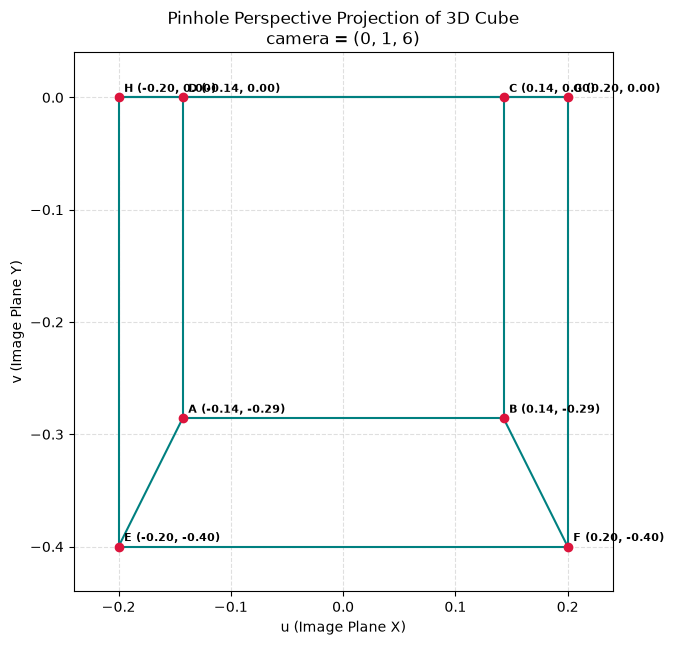

In [15]:
V, E, labels = make_cube()

camera_pos = (0, 1, 6)
U = project_vertices(V, camera_pos)
for name, (u, v) in zip(labels, U):
    print(f"{name}: ({u:+.3f}, {v:+.3f})")
fig, ax = plot_projection(U, E, labels, camera_pos)
plt.show()

In [16]:
def draw_wireframe_gl(U, E):
    from OpenGL.GL import GL_LINES, glBegin, glEnd, glVertex2f

    glBegin(GL_LINES)
    for u, v in U[E].reshape(-1, 2):
        glVertex2f(u, v)
    glEnd()

In [17]:
def run_gl(V, E, camera_pos, f=1.0, orbit=True):
    import glfw
    from OpenGL.GL import (
        GL_COLOR_BUFFER_BIT, GL_MODELVIEW, GL_PROJECTION,
        glClear, glClearColor, glColor3f, glLineWidth,
        glLoadIdentity, glMatrixMode, glOrtho,
    )

    if not glfw.init():
        raise RuntimeError("glfw failed to initialize")
    window = glfw.create_window(700, 700, "Cube Projection (GL_LINES)", None, None)
    if not window:
        glfw.terminate()
        raise RuntimeError("glfw failed to create a window")
    glfw.make_context_current(window)

    c0 = np.asarray(camera_pos, dtype=float)
    radius = np.hypot(c0[0], c0[2])
    angle0 = np.arctan2(c0[0], c0[2])

    glClearColor(1, 1, 1, 1)
    glLineWidth(2)
    while not glfw.window_should_close(window):
        if orbit:
            a = angle0 + 0.5 * glfw.get_time()
            c = np.array([radius * np.sin(a), c0[1], radius * np.cos(a)])
        else:
            c = c0
        U = project_vertices(V, c, f=f)

        # Fit the view to the projected points, keeping a square aspect.
        center = (U.min(axis=0) + U.max(axis=0)) / 2
        half = (U.max(axis=0) - U.min(axis=0)).max() / 2 * 1.2 + 1e-6
        glMatrixMode(GL_PROJECTION)
        glLoadIdentity()
        glOrtho(center[0] - half, center[0] + half, center[1] - half, center[1] + half, -1, 1)
        glMatrixMode(GL_MODELVIEW)
        glLoadIdentity()

        glClear(GL_COLOR_BUFFER_BIT)
        glColor3f(0.0, 0.5, 0.5)
        draw_wireframe_gl(U, E)

        glfw.swap_buffers(window)
        glfw.poll_events()

    glfw.terminate()

In [18]:
RUN_GL = False
if RUN_GL:
    run_gl(V, E, camera_pos)